In [1]:
"""
=========================================================
  MO-CD : Multi-Objective Community Detection Framework
          for Agile Team Formation
=========================================================

Phases:
  I   - Hybrid Population Initialization
  II  - Evolutionary Optimization via NSGA-II
  III - Post-Processing and Decision Making

Objectives (maximization):
  f1 - Social Cohesion     (intra-community density)
  f2 - Contextual Similarity (shared time slots)
  f3 - Role Complementarity  (PO, SM, Dev coverage)
"""

'\n=========================================================\n  MO-CD : Multi-Objective Community Detection Framework\n          for Agile Team Formation\n=========================================================\n\nPhases:\n  I   - Hybrid Population Initialization\n  II  - Evolutionary Optimization via NSGA-II\n  III - Post-Processing and Decision Making\n\nObjectives (maximization):\n  f1 - Social Cohesion     (intra-community density)\n  f2 - Contextual Similarity (shared time slots)\n  f3 - Role Complementarity  (PO, SM, Dev coverage)\n'

In [2]:
import random
import math
import copy
import itertools
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

random.seed(42)
np.random.seed(42)

In [3]:
# =======================================================
#  1. OBJECTIVE FUNCTIONS
# =======================================================

def intra_density(G, community):
    """
    Compute the intra-cluster density D_k(X) of a community.
    Ratio of the sum of internal edge weights to the maximum
    possible number of edges within the community.
    """
    nodes = list(community)
    n = len(nodes)
    if n < 2:
        return 0.0
    total_weight = sum(
        G[u][v].get("weight", 1)
        for u, v in itertools.combinations(nodes, 2)
        if G.has_edge(u, v)
    )
    return (2 * total_weight) / (n * (n - 1))


def f1_social_cohesion(G, partition, lam=0.3):
    """
    f1 = mean(D_k) - lambda * std(D_k)

    Maximizes average intra-community density while penalizing
    inequality between communities.

    Parameters
    ----------
    G   : social network graph with edge weights
    lam : penalty coefficient controlling the fairness trade-off
          (typical range: 0.1 to 0.5)
    """
    densities = [intra_density(G, comm) for comm in partition]
    mean_d = np.mean(densities)
    std_d  = np.std(densities)
    return mean_d - lam * std_d


def f2_contextual_similarity(partition, availability):
    """
    f2 = min_k( |intersection(S_i)| / max_i(|S_i|) )

    Maximizes the minimum shared availability across all teams.
    Focuses on the most constrained team to ensure every group
    can hold Scrum rituals (Daily Stand-up, Sprint Planning).

    Parameters
    ----------
    availability : dict mapping student -> list of available time slots
    """
    min_phi = float("inf")
    for comm in partition:
        members = list(comm)
        if not members:
            continue
        # Intersect all members' available slots
        common = set(availability[members[0]])
        for m in members[1:]:
            common &= set(availability[m])
        max_avail = max(len(availability[m]) for m in members)
        phi = len(common) / max_avail if max_avail > 0 else 0.0
        min_phi = min(min_phi, phi)
    return min_phi if min_phi != float("inf") else 0.0


def f3_role_complementarity(partition, proficiency):
    """
    f3 = (1/K) * sum_k [ product_r  max_{i in C_k} P_{i,r} ]

    Ensures every team covers all three Agile roles (PO, SM, Dev).
    The product aggregation acts as a soft constraint: if any role
    is absent in a team, the product for that team collapses to zero,
    strongly penalizing the global score.

    Parameters
    ----------
    proficiency : dict mapping student -> {role -> score in [0,1]}
    """
    roles = ["PO", "SM", "Dev"]
    total = 0.0
    for comm in partition:
        members = list(comm)
        product = 1.0
        for r in roles:
            # Best proficiency for role r within the team
            best = max(proficiency[m][r] for m in members)
            product *= best
        total += product
    return total / len(partition)


def evaluate(individual, G, availability, proficiency, lam=0.3):
    """
    Evaluate all three objective functions for a given individual
    (encoded as a community assignment vector).

    Returns
    -------
    tuple : (f1_score, f2_score, f3_score)
    """
    partition = individual_to_partition(individual)
    return (
        f1_social_cohesion(G, partition, lam),
        f2_contextual_similarity(partition, availability),
        f3_role_complementarity(partition, proficiency),
    )

In [4]:
# =======================================================
#  2. ENCODING  individual <-> partition
# =======================================================

def individual_to_partition(individual):
    """
    Convert a flat assignment vector to a list of community sets.

    Example: [0,1,0,2,1] -> [{0,2}, {1,4}, {3}]
    """
    groups = defaultdict(set)
    for node, comm in enumerate(individual):
        groups[comm].add(node)
    return list(groups.values())


def partition_to_individual(partition, n):
    """
    Convert a list of community sets to a flat assignment vector.

    Example: [{0,2}, {1,3}, {4,5}] -> [0,1,0,1,2,2]
    """
    individual = [0] * n
    for k, comm in enumerate(partition):
        for node in comm:
            individual[node] = k
    return individual


In [5]:
# =======================================================
#  3. PHASE I — HYBRID POPULATION INITIALIZATION
# =======================================================

def louvain_seeding(G, K, n):
    """
    Exploitative seeding (10% of population) using a Louvain-based
    greedy heuristic. Detects natural social clusters in the network,
    then merges or splits them to obtain exactly K balanced communities.

    This warm-start provides high-quality initial solutions specifically
    optimized for the social cohesion objective (f1).
    """
    # Detect communities via greedy modularity maximization (NetworkX)
    try:
        from networkx.algorithms.community import greedy_modularity_communities
        communities = list(greedy_modularity_communities(G, weight="weight"))
    except Exception:
        # Fallback: single community containing all nodes
        communities = [set(G.nodes())]

    # Adjust to obtain exactly K groups of balanced size (~n/K)
    communities = [list(c) for c in communities]

    # Merge communities if there are too many
    while len(communities) > K:
        communities.sort(key=len)
        communities[0] += communities.pop(1)

    # Split the largest community if there are not enough
    while len(communities) < K:
        communities.sort(key=len, reverse=True)
        big  = communities.pop(0)
        half = len(big) // 2
        communities.extend([big[:half], big[half:]])

    return repair(partition_to_individual(
        [set(c) for c in communities], n), n, K)


def random_balanced_partitioning(n, K):
    """
    Explorative random balanced partitioning (90% of population).
    Each student is assigned to a team such that community sizes
    satisfy the min/max size constraints. Ensures broad sampling
    of the search space and prevents premature convergence.
    """
    nodes = list(range(n))
    random.shuffle(nodes)
    individual = [0] * n
    for i, node in enumerate(nodes):
        individual[node] = i % K
    return individual


def repair(individual, n, K):
    """
    Feasibility repair heuristic.
    Ensures every community has at least one member and that sizes
    satisfy balanced constraints (n_min and n_max per team).

    The number of oversized and undersized communities is resolved
    by transferring students until all constraints are met.
    """
    n_min = n // K
    n_max = n_min + (1 if n % K != 0 else 0)

    counts = defaultdict(list)
    for node, comm in enumerate(individual):
        counts[comm].append(node)

    # Ensure all K communities exist (create missing ones)
    all_comms = set(range(K))
    missing   = all_comms - set(counts.keys())
    for m in missing:
        # Steal a node from an oversized community
        for c, nodes in counts.items():
            if len(nodes) > n_min:
                node = nodes.pop()
                individual[node] = m
                counts[m].append(node)
                break

    # Balance community sizes
    for _ in range(n * 2):
        over  = [c for c, ns in counts.items() if len(ns) > n_max]
        under = [c for c, ns in counts.items() if len(ns) < n_min]
        if not over or not under:
            break
        src, dst = over[0], under[0]
        node = counts[src].pop()
        individual[node] = dst
        counts[dst].append(node)

    return individual


def initialize_population(G, K, pop_size, n):
    """
    Build the hybrid initial population:
      - 10% : Louvain-seeded solutions (exploitative)
      - 90% : random balanced partitions (explorative)

    This balance promotes both fast convergence and broad search
    coverage, mitigating premature convergence to local optima.
    """
    population = []
    n_louvain  = max(1, int(0.1 * pop_size))

    # Exploitative seeding (Louvain heuristic)
    for _ in range(n_louvain):
        ind = louvain_seeding(G, K, n)
        population.append(ind)

    # Explorative random seeding
    for _ in range(pop_size - n_louvain):
        ind = random_balanced_partitioning(n, K)
        ind = repair(ind, n, K)
        population.append(ind)

    return population


In [6]:
# =======================================================
#  4. PHASE II — NSGA-II EVOLUTIONARY OPTIMIZATION
# =======================================================

def dominates(a, b):
    """
    Return True if solution a dominates solution b.
    a dominates b if a is at least as good on all objectives
    and strictly better on at least one.
    """
    better_in_one = False
    for ai, bi in zip(a, b):
        if ai < bi:
            return False       # a is worse on at least one objective
        if ai > bi:
            better_in_one = True
    return better_in_one


def fast_non_dominated_sort(fitnesses):
    """
    Fast non-dominated sorting procedure (Deb et al., 2002).
    Assigns each individual to a Pareto front F1, F2, ...
    F1 contains the best non-dominated solutions (the Pareto front).

    Returns
    -------
    list of fronts, each front being a list of individual indices
    """
    n   = len(fitnesses)
    S   = [[] for _ in range(n)]   # S[i] = list of solutions dominated by i
    n_dom = [0] * n                # n_dom[i] = number of solutions dominating i
    fronts = [[]]

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if dominates(fitnesses[i], fitnesses[j]):
                S[i].append(j)
            elif dominates(fitnesses[j], fitnesses[i]):
                n_dom[i] += 1
        if n_dom[i] == 0:
            fronts[0].append(i)   # i belongs to the first Pareto front

    current = 0
    while fronts[current]:
        next_front = []
        for i in fronts[current]:
            for j in S[i]:
                n_dom[j] -= 1
                if n_dom[j] == 0:
                    next_front.append(j)
        current += 1
        fronts.append(next_front)

    return [f for f in fronts if f]


def crowding_distance(front, fitnesses):
    """
    Compute the crowding distance for each individual in a front.
    Individuals in less-crowded regions of the objective space receive
    a higher distance, promoting diversity along the Pareto front.

    Returns
    -------
    dict mapping individual index -> crowding distance
    """
    n_obj     = len(fitnesses[0])
    distances = {i: 0.0 for i in front}

    for obj in range(n_obj):
        sorted_front = sorted(front, key=lambda i: fitnesses[i][obj])
        # Boundary solutions get infinite distance (always kept)
        distances[sorted_front[0]]  = float("inf")
        distances[sorted_front[-1]] = float("inf")
        f_min = fitnesses[sorted_front[0]][obj]
        f_max = fitnesses[sorted_front[-1]][obj]
        if f_max == f_min:
            continue
        for k in range(1, len(sorted_front) - 1):
            distances[sorted_front[k]] += (
                fitnesses[sorted_front[k + 1]][obj]
                - fitnesses[sorted_front[k - 1]][obj]
            ) / (f_max - f_min)
    return distances


def tournament_selection(population, fitnesses, fronts, distances, k=2):
    """
    Binary tournament selection based on NSGA-II dominance ranking.
    Primary criterion  : Pareto front rank (lower is better)
    Tie-breaker        : crowding distance (higher is better)

    Promotes propagation of high-quality and diverse solutions.
    """
    rank = {}
    for r, front in enumerate(fronts):
        for i in front:
            rank[i] = r

    candidates = random.sample(range(len(population)), k)
    best = candidates[0]
    for c in candidates[1:]:
        if rank[c] < rank[best]:
            best = c
        elif rank[c] == rank[best] and distances.get(c, 0) > distances.get(best, 0):
            best = c
    return population[best]


def community_crossover(parent1, parent2, n, K):
    """
    Community-based crossover operator.

    Selects m communities from parent1 and transfers them unchanged
    to the offspring. Remaining students are assigned according to
    parent2. A cardinality-aware repair heuristic is then applied to
    resolve duplicates and enforce balanced size constraints.
    """
    m = random.randint(1, K - 1)
    selected_comms = random.sample(range(K), m)

    child     = [-1] * n
    inherited = set()

    # Inherit selected communities from parent1
    for node in range(n):
        if parent1[node] in selected_comms:
            child[node] = parent1[node]
            inherited.add(node)

    # Fill remaining nodes from parent2
    for node in range(n):
        if child[node] == -1:
            c2 = parent2[node]
            child[node] = c2 if c2 < K else random.randint(0, K - 1)

    return repair(child, n, K)


def swap_mutation(individual, n, K, prob=0.1):
    """
    Swap-based mutation operator.

    Two students from different communities exchange their assignments.
    This operation preserves community sizes, inherently satisfying
    the n_min and n_max constraints without repair.
    """
    if random.random() > prob:
        return individual[:]
    child = individual[:]
    a, b  = random.sample(range(n), 2)
    if child[a] != child[b]:
        child[a], child[b] = child[b], child[a]
    return child


def nsga2(G, availability, proficiency, K, pop_size, n_gen, n, lam=0.3):
    """
    Main NSGA-II evolutionary loop.

    At each generation:
      1. Rank individuals using fast non-dominated sorting.
      2. Compute crowding distances within each front.
      3. Generate offspring via tournament selection, crossover,
         mutation, and repair.
      4. Combine parent and offspring populations.
      5. Select the next generation using rank and crowding distance.

    Returns
    -------
    population : list of individuals in the final generation
    fitnesses  : list of (f1, f2, f3) tuples for each individual
    """
    # --- Initialize population ---
    population = initialize_population(G, K, pop_size, n)
    fitnesses  = [evaluate(ind, G, availability, proficiency, lam)
                  for ind in population]

    for gen in range(n_gen):
        # Non-dominated sorting + crowding distance
        fronts   = fast_non_dominated_sort(fitnesses)
        all_dist = {}
        for front in fronts:
            all_dist.update(crowding_distance(front, fitnesses))

        # Generate offspring population
        offspring     = []
        offspring_fit = []
        while len(offspring) < pop_size:
            p1    = tournament_selection(population, fitnesses, fronts, all_dist)
            p2    = tournament_selection(population, fitnesses, fronts, all_dist)
            child = community_crossover(p1, p2, n, K)
            child = swap_mutation(child, n, K, prob=0.15)
            child = repair(child, n, K)
            offspring.append(child)
            offspring_fit.append(
                evaluate(child, G, availability, proficiency, lam))

        # Combine parent + offspring (elitist strategy)
        combined     = population + offspring
        combined_fit = fitnesses  + offspring_fit

        # Re-rank combined population
        fronts   = fast_non_dominated_sort(combined_fit)
        all_dist = {}
        for front in fronts:
            all_dist.update(crowding_distance(front, combined_fit))

        # Build next generation using rank then crowding distance
        new_pop, new_fit = [], []
        for front in fronts:
            if len(new_pop) + len(front) <= pop_size:
                for i in front:
                    new_pop.append(combined[i])
                    new_fit.append(combined_fit[i])
            else:
                # Fill remaining slots with the most spread individuals
                remaining    = pop_size - len(new_pop)
                sorted_front = sorted(front, key=lambda i: -all_dist.get(i, 0))
                for i in sorted_front[:remaining]:
                    new_pop.append(combined[i])
                    new_fit.append(combined_fit[i])
                break

        population, fitnesses = new_pop, new_fit

    return population, fitnesses


In [7]:
# =======================================================
#  5. PHASE III — POST-PROCESSING & DECISION MAKING
# =======================================================

def conflict_filtering(population, fitnesses, fronts, conflict_matrix, n):
    """
    Conflict filtering step.

    Cross-references Pareto-optimal solutions with the conflict matrix.
    Any solution that places two students with a known high-conflict
    history in the same team is automatically eliminated, prioritizing
    group psychological safety over raw optimization scores.

    If all Pareto solutions violate some conflict, the full front is
    kept (fallback) to guarantee a non-empty candidate set.
    """
    valid_pop, valid_fit = [], []
    for i in fronts[0]:   # examine only the first Pareto front (F1)
        ind   = population[i]
        valid = True
        for (u, v) in conflict_matrix:
            if ind[u] == ind[v]:   # conflicting students in the same team
                valid = False
                break
        if valid:
            valid_pop.append(population[i])
            valid_fit.append(fitnesses[i])

    # Fallback: keep the full Pareto front if all solutions are conflicting
    if not valid_pop:
        for i in fronts[0]:
            valid_pop.append(population[i])
            valid_fit.append(fitnesses[i])
    return valid_pop, valid_fit


def utopia_point_selection(valid_pop, valid_fit):
    """
    Utopia Point selection.

    Selects the most balanced solution by minimizing the normalized
    Euclidean distance to the Utopia Point U(1, 1, 1), which represents
    a theoretical solution achieving perfect scores on all objectives.

    Returns
    -------
    best individual and its fitness tuple
    """
    utopia = np.array([1.0, 1.0, 1.0])
    fits   = np.array(valid_fit)

    # Normalize scores to [0, 1] for fair distance computation
    f_min   = fits.min(axis=0)
    f_max   = fits.max(axis=0)
    denom   = np.where(f_max - f_min > 0, f_max - f_min, 1)
    norm_fits = (fits - f_min) / denom

    distances = np.linalg.norm(norm_fits - utopia, axis=1)
    best_idx  = np.argmin(distances)
    return valid_pop[best_idx], valid_fit[best_idx]


def mocd(G, availability, proficiency, conflict_matrix,
         K=3, pop_size=50, n_gen=100, lam=0.3):
    """
    Main entry point of the MO-CD framework.

    Parameters
    ----------
    G               : social network graph (NetworkX Graph with edge weights)
    availability    : dict {student: [available_slots]}
    proficiency     : dict {student: {"PO": float, "SM": float, "Dev": float}}
    conflict_matrix : list of (student_a, student_b) conflict pairs
    K               : number of teams to form
    pop_size        : NSGA-II population size
    n_gen           : number of generations
    lam             : penalty coefficient for f1 fairness term

    Returns
    -------
    best_ind : optimal team assignment vector X*
    best_fit : tuple (f1, f2, f3) scores of the selected solution
    """
    n = G.number_of_nodes()
    print("=" * 57)
    print("   MO-CD Framework  --  Agile Team Formation")
    print("=" * 57)
    print(f"   Students : {n}  |  Teams : {K}")
    print(f"   Population : {pop_size}  |  Generations : {n_gen}")
    print("-" * 57)

    # --- Phase I & II : Initialization + NSGA-II ---
    print("   > Phase I  : Hybrid population initialization ...")
    print("   > Phase II : NSGA-II running ...")
    population, fitnesses = nsga2(
        G, availability, proficiency, K, pop_size, n_gen, n, lam)

    # --- Phase III : Post-processing ---
    print("   > Phase III: Conflict filtering & final selection ...")
    fronts = fast_non_dominated_sort(fitnesses)
    valid_pop, valid_fit = conflict_filtering(
        population, fitnesses, fronts, conflict_matrix, n)
    best_ind, best_fit = utopia_point_selection(valid_pop, valid_fit)

    print("-" * 57)
    print("   [OK] Optimal solution found!")
    print(f"        f1  Social Cohesion       = {best_fit[0]:.4f}")
    print(f"        f2  Contextual Similarity = {best_fit[1]:.4f}")
    print(f"        f3  Role Complementarity  = {best_fit[2]:.4f}")
    print("=" * 57)
    return best_ind, best_fit


In [8]:
# =======================================================
#  6. EXAMPLE  --  12-STUDENT SOCIAL NETWORK, 3 TEAMS
# =======================================================

def build_example():
    """
    Build a synthetic social network of 12 students containing:
      - Weighted social ties (affinity scores)
      - Time slot availability vectors
      - Agile role proficiency profiles (PO, SM, Dev)
      - A conflict matrix (incompatible student pairs)

    Three natural clusters are embedded in the graph:
      Cluster A : {S0, S1, S2, S3}  -- morning availability
      Cluster B : {S4, S5, S6, S7}  -- afternoon availability
      Cluster C : {S8, S9, S10,S11} -- evening availability
    """
    n        = 12
    students = list(range(n))
    labels   = [f"S{i}" for i in students]

    # ── Social network graph ───────────────────────────
    G = nx.Graph()
    G.add_nodes_from(students)

    edges = [
        # Cluster A (strong internal ties)
        (0, 1, 0.9), (0, 2, 0.8), (0, 3, 0.7),
        (1, 2, 0.9), (1, 3, 0.6), (2, 3, 0.8),
        # Cluster B (strong internal ties)
        (4, 5, 0.9), (4, 6, 0.8), (4, 7, 0.7),
        (5, 6, 0.85),(5, 7, 0.6), (6, 7, 0.75),
        # Cluster C (strong internal ties)
        (8, 9, 0.9), (8,10, 0.8), (8,11, 0.85),
        (9,10, 0.9), (9,11, 0.7),(10,11, 0.8),
        # Weak inter-cluster ties
        (3, 4, 0.2), (7, 8, 0.15), (0, 11, 0.1),
        (2, 5, 0.2), (6, 9, 0.15),
    ]
    for u, v, w in edges:
        G.add_edge(u, v, weight=w)

    # ── Availability (time slots 0..9) ────────────────
    avail = {
        # Cluster A : mainly morning slots (0-5)
        0:  [0,1,2,3,4,5],
        1:  [0,1,2,3,4],
        2:  [1,2,3,4,5],
        3:  [0,1,2,3],
        # Cluster B : mainly afternoon slots (3-8)
        4:  [3,4,5,6,7],
        5:  [3,4,5,6,7,8],
        6:  [4,5,6,7],
        7:  [3,4,5,6],
        # Cluster C : mainly evening slots (5-9)
        8:  [6,7,8,9],
        9:  [6,7,8,9],
        10: [5,6,7,8,9],
        11: [6,7,8,9],
    }

    # ── Agile role proficiency scores (0.0 - 1.0) ─────
    prof = {
        0:  {"PO": 0.9, "SM": 0.3, "Dev": 0.5},  # Product Owner profile
        1:  {"PO": 0.4, "SM": 0.3, "Dev": 0.9},  # Senior Developer
        2:  {"PO": 0.3, "SM": 0.2, "Dev": 0.8},  # Developer
        3:  {"PO": 0.5, "SM": 0.8, "Dev": 0.4},  # Scrum Master
        4:  {"PO": 0.8, "SM": 0.4, "Dev": 0.5},  # Product Owner
        5:  {"PO": 0.3, "SM": 0.3, "Dev": 0.9},  # Senior Developer
        6:  {"PO": 0.4, "SM": 0.9, "Dev": 0.3},  # Scrum Master
        7:  {"PO": 0.5, "SM": 0.4, "Dev": 0.8},  # Developer
        8:  {"PO": 0.7, "SM": 0.5, "Dev": 0.6},  # PO / Developer
        9:  {"PO": 0.4, "SM": 0.4, "Dev": 0.9},  # Developer
        10: {"PO": 0.3, "SM": 0.9, "Dev": 0.4},  # Scrum Master
        11: {"PO": 0.6, "SM": 0.5, "Dev": 0.7},  # Developer / PO
    }

    # ── Conflict matrix (incompatible student pairs) ───
    # These students must not be placed in the same team
    conflicts = [(1, 9), (3, 7)]

    return G, avail, prof, conflicts, labels


In [9]:
# =======================================================
#  7. VISUALIZATION
# =======================================================

PALETTE = ["#E63946", "#2A9D8F", "#E9C46A", "#457B9D", "#F4A261"]


def dominant_role(prof_dict):
    """Return the role with the highest proficiency score."""
    return max(prof_dict, key=prof_dict.get)


def visualize(G, labels, best_ind, best_fit, K, proficiency,
              save_path="mocd_communities.png"):
    """
    Visualize the social network decomposed into communities,
    with a results panel showing objective scores and team composition.

    Parameters
    ----------
    G           : social network graph
    labels      : node label list
    best_ind    : optimal assignment vector
    best_fit    : tuple (f1, f2, f3) scores
    K           : number of teams
    proficiency : role proficiency dict (used to label dominant roles)
    save_path   : output file path (relative or absolute).
                  Defaults to "mocd_communities.png" in the current directory.
    """
    # ── Color and role mapping ─────────────────────────
    node_colors = [PALETTE[best_ind[i] % len(PALETTE)] for i in G.nodes()]
    partition   = individual_to_partition(best_ind)
    role_of     = {i: dominant_role(proficiency[i])
                   for i in range(len(proficiency))}

    # ── Figure layout: left (graph) + right (results panel) ──
    fig = plt.figure(figsize=(16, 9), facecolor="#12151e")
    gs  = fig.add_gridspec(1, 2, width_ratios=[2.6, 1], wspace=0.05,
                           left=0.02, right=0.98, top=0.93, bottom=0.04)
    ax_g = fig.add_subplot(gs[0])
    ax_p = fig.add_subplot(gs[1])
    ax_g.set_facecolor("#12151e")
    ax_p.set_facecolor("#1a1e2e")

    # =====================================================
    #  LEFT PANEL -- Social Network Graph
    # =====================================================
    pos = nx.spring_layout(G, seed=7, k=2.8, weight="weight")

    intra_edges = [(u, v) for u, v in G.edges() if best_ind[u] == best_ind[v]]
    inter_edges = [(u, v) for u, v in G.edges() if best_ind[u] != best_ind[v]]

    # Inter-community edges (grey, thin -- weak ties)
    nx.draw_networkx_edges(
        G, pos, edgelist=inter_edges,
        width=[G[u][v]["weight"] for u, v in inter_edges],
        alpha=0.15, edge_color="#888888", ax=ax_g)

    # Intra-community edges (colored per team -- strong ties)
    for k in range(K):
        edges_k  = [(u, v) for u, v in intra_edges if best_ind[u] == k]
        widths_k = [G[u][v]["weight"] * 4 for u, v in edges_k]
        nx.draw_networkx_edges(
            G, pos, edgelist=edges_k, width=widths_k,
            alpha=0.75, edge_color=PALETTE[k % len(PALETTE)], ax=ax_g)

    # Nodes
    nx.draw_networkx_nodes(
        G, pos, node_color=node_colors,
        node_size=1000, alpha=0.97, ax=ax_g,
        linewidths=2.5, edgecolors="white")
    nx.draw_networkx_labels(
        G, pos,
        labels={i: f"S{i}" for i in G.nodes()},
        font_size=9, font_color="white", font_weight="bold", ax=ax_g)

    ax_g.set_title(
        "Social Network  --  Community Decomposition  (MO-CD)",
        color="white", fontsize=13, fontweight="bold", pad=12)
    ax_g.axis("off")

    # Team legend
    legend_patches = [
        mpatches.Patch(color=PALETTE[k % len(PALETTE)], label=f"Team {k+1}")
        for k in range(K)
    ]
    ax_g.legend(
        handles=legend_patches, loc="lower left",
        framealpha=0.3, labelcolor="white",
        fontsize=10, facecolor="#1a1e2e",
        edgecolor="#444444", borderpad=0.8)

    # =====================================================
    #  RIGHT PANEL -- Results Summary
    # =====================================================
    ax_p.set_xlim(0, 1)
    ax_p.set_ylim(0, 1)
    ax_p.axis("off")

    for spine in ["top", "bottom", "left", "right"]:
        ax_p.spines[spine].set_visible(False)

    def txt(x, y, s, **kw):
        """Shortcut for ax_p.text with axes transform."""
        ax_p.text(x, y, s, transform=ax_p.transAxes, **kw)

    def hline(y, color="#333344", lw=0.8):
        """Draw a horizontal separator line."""
        ax_p.plot([0.03, 0.97], [y, y], color=color,
                  linewidth=lw, transform=ax_p.transAxes, clip_on=False)

    # ── Panel title ───────────────────────────────────
    txt(0.5, 0.965, "MO-CD Results",
        ha="center", va="top", fontsize=12, fontweight="bold", color="white")
    hline(0.935)

    # ── Objective scores section ───────────────────────
    txt(0.05, 0.905, "Objective Scores",
        ha="left", va="top", fontsize=9, color="#aaaacc", fontweight="bold")

    scores_info = [
        ("f1  --  Social Cohesion",        best_fit[0], "#E63946"),
        ("f2  --  Contextual Similarity",   best_fit[1], "#2A9D8F"),
        ("f3  --  Role Complementarity",    best_fit[2], "#E9C46A"),
    ]

    y_s   = 0.870
    BAR_H = 0.022
    BAR_GAP = 0.072

    for label, val, col in scores_info:
        # Objective label
        txt(0.05, y_s, label,
            ha="left", va="center", fontsize=8.5, color="#cccccc")
        # Grey background bar
        ax_p.add_patch(mpatches.FancyBboxPatch(
            (0.05, y_s - BAR_H - 0.008), 0.90, BAR_H,
            boxstyle="round,pad=0.003", color="#2a2d3e", alpha=1.0,
            transform=ax_p.transAxes, zorder=1))
        # Colored value bar
        bar_w = max(0.04, val * 0.90)
        ax_p.add_patch(mpatches.FancyBboxPatch(
            (0.05, y_s - BAR_H - 0.008), bar_w, BAR_H,
            boxstyle="round,pad=0.003", color=col, alpha=0.85,
            transform=ax_p.transAxes, zorder=2))
        # Numeric value
        txt(0.96, y_s - BAR_H / 2 - 0.008, f"{val:.3f}",
            ha="right", va="center", fontsize=8, color=col, fontweight="bold")
        y_s -= BAR_GAP

    hline(y_s + 0.01)

    # ── Team composition section ───────────────────────
    y_s -= 0.010
    txt(0.05, y_s, "Team Composition",
        ha="left", va="top", fontsize=9, color="#aaaacc", fontweight="bold")
    y_s -= 0.045

    communities_sorted = sorted(partition, key=lambda c: min(c))

    CARD_H   = 0.115
    CARD_GAP = 0.125

    for k, comm in enumerate(communities_sorted):
        col     = PALETTE[k % len(PALETTE)]
        members = sorted(comm)

        # Card background
        ax_p.add_patch(mpatches.FancyBboxPatch(
            (0.03, y_s - CARD_H), 0.94, CARD_H,
            boxstyle="round,pad=0.008", color=col, alpha=0.10,
            transform=ax_p.transAxes, zorder=0))
        # Left color accent bar
        ax_p.add_patch(mpatches.FancyBboxPatch(
            (0.03, y_s - CARD_H), 0.035, CARD_H,
            boxstyle="round,pad=0.002", color=col, alpha=0.90,
            transform=ax_p.transAxes, zorder=1))

        # Team title
        txt(0.11, y_s - 0.018,
            f"Team {k+1}  ({len(members)} members)",
            ha="left", va="top", fontsize=9, color=col, fontweight="bold")

        # Member list with dominant roles (2-column layout)
        lines = [f"S{m}  --  {role_of[m]}" for m in members]
        mid   = math.ceil(len(lines) / 2)
        col1, col2 = lines[:mid], lines[mid:]

        for row_i, line in enumerate(col1):
            txt(0.11, y_s - 0.044 - row_i * 0.022,
                line, ha="left", va="top", fontsize=7.8, color="#dddddd")
        for row_i, line in enumerate(col2):
            txt(0.55, y_s - 0.044 - row_i * 0.022,
                line, ha="left", va="top", fontsize=7.8, color="#dddddd")

        y_s -= CARD_GAP

    hline(y_s + 0.01)

    # ── Methodological footer ─────────────────────────
    txt(0.5, 0.040,
        "Method: NSGA-II  |  Selection: Utopia Point",
        ha="center", va="center", fontsize=7.5, color="#666688",
        style="italic")
    txt(0.5, 0.018,
        "Conflict Filtering  |  Hybrid Louvain Initialization",
        ha="center", va="center", fontsize=7.5, color="#666688",
        style="italic")

    # ── Save figure ───────────────────────────────────
    out_dir = os.path.dirname(os.path.abspath(save_path))
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#12151e")
    plt.show()
    print(f"\n  [OK] Graph saved: {os.path.abspath(save_path)}")


   MO-CD Framework  --  Agile Team Formation
   Students : 12  |  Teams : 3
   Population : 60  |  Generations : 80
---------------------------------------------------------
   > Phase I  : Hybrid population initialization ...
   > Phase II : NSGA-II running ...
   > Phase III: Conflict filtering & final selection ...
---------------------------------------------------------
   [OK] Optimal solution found!
        f1  Social Cohesion       = 0.7843
        f2  Contextual Similarity = 0.5000
        f3  Role Complementarity  = 0.6210


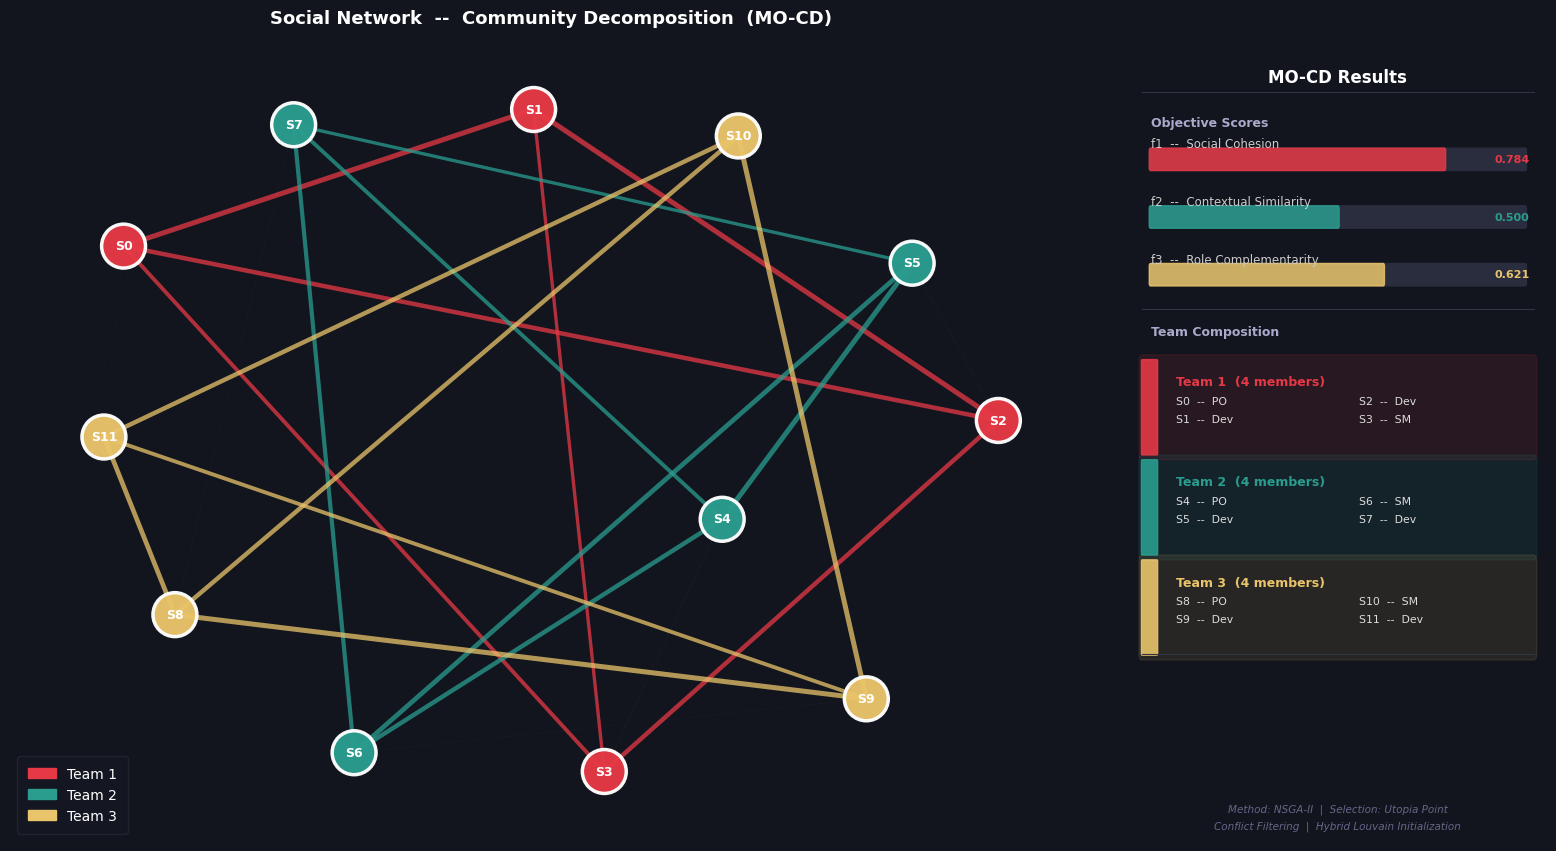


  [OK] Graph saved: C:\Users\ADMIN\mocd_communities.png


In [10]:
# =======================================================
#  8. MAIN
# =======================================================
# NOTE FOR JUPYTER USERS:
#   If you run this code cell by cell in a notebook, paste
#   the imports below into your last cell to avoid NameError
#   caused by Jupyter's partial scope isolation.
# =======================================================

import random, math, copy, itertools, os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

random.seed(42)
np.random.seed(42)

G, availability, proficiency, conflicts, labels = build_example()

best_ind, best_fit = mocd(
    G,
    availability,
    proficiency,
    conflict_matrix=conflicts,
    K=3,
    pop_size=60,
    n_gen=80,
    lam=0.3,
)

visualize(
    G, labels, best_ind, best_fit,
    K=3,
    proficiency=proficiency,
    save_path="mocd_communities.png",   # saved in the current working directory
)
